# 🚚 Proyecto DS II · Exploratorio de Logística  
**⏱️ Período analizado:** ene-2021 → ene-2024  
**👨‍💻 Autor:** Cristian Emanuel Campos Fuentes | [@LinkedIn](https://linkedin.com/in/cristian-emanuel-campos-fuentes)     
**📂 Repositorio:** [data-science-portfolio](https://github.com/CristianEmanuelCamposFuentes/data-science-portfolio)    
**📬 Contacto:** cristianemanuelcamposfuentes@hotmail.com   





---



## Intro
***¿Por qué este tema?***    
En la industria logística, cada demora, cada hora extra de tránsito o inventario mal gestionado se traduce en costos directos, multas por incumplimientos y pérdida de confianza del cliente.

Este estudio busca descubrir qué variables operativas predicen retrasos y cómo priorizar acciones de mejora.

## Motivación y Audiencia
Este análisis beneficia a:

*   Responsables de operaciones logísticas que necesitan detectar cuellos de botella y priorizar inversiones (flota, almacén, rutas).

*   Analistas de datos que buscan un caso real para aplicar modelos predictivos de riesgo y retrasos.

*   Partners tecnológicos (IoT, telemática) interesados en demostrar el valor de la captura de datos en tiempo real.

## Contexto Comercial / Analítico
El estudio cubre una red logística en el sur de California (2021-2024), región caracterizada por:

*   Alta congestión urbana y portuaria (puertos de Los Ángeles / Long Beach).
*   Rutas mixtas (camión, tren y drones piloto) con fluctuaciones de clima costero.
*   Operaciones <i>just-in-time</i> para retail y manufactura ligera, donde +/- 2 h de ETA impactan líneas de producción.

Analizar este entorno permite generalizar hallazgos a otras zonas de tráfico intenso (p. ej. Ciudad de México, São Paulo, Shanghái) y justificar iniciativas de optimización de última milla y gestión de inventarios.



## Hipótesis en forma de preguntas
- Hipótesis 1: ¿Cuándo se disparan los tiempos de entrega?
- Hipótesis 2: ¿El nivel de inventario influye en la puntualidad?
- Hipótesis 3: ¿Qué tan crítico es el tráfico en ruta?
- Hipótesis 4: 	¿Los costos de combustible anticipan riesgos?
- Hipótesis 5:	¿Podemos clasificar envíos en bajo / medio / alto riesgo?



---



## Dataset

  [Link al Dataset alojado en Google Drive](https://drive.google.com/file/d/1PoujPnhbTxcfyewoCNSexiOmTE9NMw7r/view?usp=drive_link)

- **Origen:** Kaggle · *Logistics and Supply Chain Dataset*  
- **Cobertura temporal:** Ene-2021 → Ene-2024 (registros cada hora)  
- **Observaciones:** 32 065 filas · 26 columnas
- **Variables operativas clave:**
  - `fuel_consumption_rate` · litros/h
  - `traffic_congestion_level` · escala 0-10
  - `warehouse_inventory_level` · unidades
  - `eta_variation_hours` · diferencia ETA real-plan
  - `shipping_costs` · USD
  - `supplier_reliability_score`, `route_risk_level`, `driver_behavior_score` (0-1)
- **Etiquetas para ML**  
  `delay_probability`, `disruption_likelihood_score`, `risk_classification` (Bajo/Medio/Alto)
- **Fuentes de captura:** GPS de flota, sensores IoT, WMS, API meteorológica y datos de congestión portuaria.
- **Caso de uso:** Evaluar riesgo de retraso, optimizar rutas y dimensionar inventarios de seguridad.


> <small>⚠️ Los CSV completos se almacenan en Google Drive (≈ 15 MB) y se cargan dinámicamente para no inflar el repositorio.</small>



---



## Objetivo del Notebook


1.   Explorar tendencias y correlaciones clave
2.   Generar insights accionables (p. ej. “a partir de X nivel de congestión el ETA se duplica”)
3.   Preparar los datos para modelos predictivos en la siguiente etapa del proyecto.



---



# Lectura inicial de datos y configuración inicial

## Librerias necesarias para el analisis de datos

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Configuración general de gráficos
%matplotlib inline
sns.set(style="whitegrid")

warnings.filterwarnings('ignore')

In [2]:
# ==== Entorno Colab + Lectura optimizada del dataset ====
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("CWD antes:", os.getcwd())

# Cambiar el directorio de trabajo
os.chdir('/content/drive/My Drive/CODERHOUSE/Data Science II/Primera Entrega')
print("CWD ahora:", os.getcwd())

# Columnas
num_cols = [
    'vehicle_gps_latitude','vehicle_gps_longitude','fuel_consumption_rate','eta_variation_hours',
    'traffic_congestion_level','warehouse_inventory_level','loading_unloading_time',
    'handling_equipment_availability','order_fulfillment_status','weather_condition_severity',
    'port_congestion_level','shipping_costs','supplier_reliability_score','lead_time_days',
    'historical_demand','iot_temperature','cargo_condition_status','route_risk_level',
    'customs_clearance_time','driver_behavior_score','fatigue_monitoring_score',
    'disruption_likelihood_score','delay_probability','delivery_time_deviation'
]
cat_cols = ['risk_classification']

dtype_map = {c: 'float32' for c in num_cols}
dtype_map.update({c: 'category' for c in cat_cols})
usecols = ['timestamp', *num_cols, *cat_cols]

# Lectura
df = (
    pd.read_csv(
        'dynamic_supply_chain_logistics_dataset.csv',
        usecols=usecols,
        dtype=dtype_map,
        parse_dates=['timestamp']  # timestamp -> datetime
    )
    .sort_values('timestamp')     # orden temporal
    .reset_index(drop=True)
)

# Casteo a int8 solo si la columna es estrictamente binaria {0,1}
bin_candidates = ['order_fulfillment_status','handling_equipment_availability','cargo_condition_status']
for c in bin_candidates:
    if c in df.columns:
        vals = pd.Series(df[c].dropna().unique())
        if set(np.unique(vals)).issubset({0, 1, 0.0, 1.0}):
            df[c] = df[c].astype('int8')

def mem_mb(x):
    return x.memory_usage(deep=True).sum() / (1024**2)

print(f"Memoria tras lectura: {mem_mb(df):.2f} MB")
display(df.tail(3))

ModuleNotFoundError: No module named 'google.colab'

 Se observan muchos tipos `float32`, lo que facilitará el uso del dataset presentado para usarlo en modelos de Machine Learning.




---



##  Exploración inicial del dataset (Tamaño, Estructura y Estadísticas)

In [ ]:
# === MUESTRA PARA EDA: liviana y estratificada ===
from sklearn.model_selection import train_test_split
import pandas as pd

EDA_FRAC = 0.30
RANDOM_STATE = 42

def make_eda_sample(df, frac=0.30, random_state=42, target_col='delivery_time_deviation'):
    frac = float(frac)
    assert 0 < frac < 1, "frac debe estar entre 0 y 1"

    df_shuf = df.sample(frac=1.0, random_state=random_state)  # barajar para evitar sesgos

    # 1) Clasificación:
    if 'risk_classification' in df_shuf.columns:
        vc = df_shuf['risk_classification'].value_counts(dropna=True)
        if (vc.size >= 2) and (vc.min() >= 2):
            try:
                _, eda = train_test_split(
                    df_shuf,
                    test_size=frac,
                    stratify=df_shuf['risk_classification'],
                    random_state=random_state
                )
                return eda.reset_index(drop=True)
            except ValueError:
                pass

    # 2) Regresión:
    if (target_col in df_shuf.columns):
        try:
            # qcut puede colapsar bins si hay muchos duplicados; duplicates='drop' lo maneja
            bins = pd.qcut(df_shuf[target_col], q=5, duplicates='drop')
            if bins.nunique() >= 2:
                _, eda = train_test_split(
                    df_shuf,
                    test_size=frac,
                    stratify=bins,
                    random_state=random_state
                )
                return eda.reset_index(drop=True)
        except Exception:
            pass  # cualquier error -> fallback

    # 3) Fallback: simple sample aleatorio
    return df_shuf.sample(frac=frac, random_state=random_state).reset_index(drop=True)

eda_df = make_eda_sample(df, frac=EDA_FRAC, random_state=RANDOM_STATE)
data_eda = eda_df  # alias para usar en plots: data=df -> data=data_eda

print("Shapes -> df completo:", df.shape, " |  data_eda:", data_eda.shape)


Shapes -> df completo: (32065, 26)  |  data_eda: (9620, 26)




---



### Descripcion de variables


In [ ]:
# Revisión general de columnas y tipos de datos

print(f"Filas/columnas en data_eda: {data_eda.shape}")

cols_summary = pd.DataFrame({
    "dtype": data_eda.dtypes.astype(str),
    "n_unique": data_eda.nunique(),
    "n_missing": data_eda.isna().sum()
}).sort_index()

display(cols_summary)

Filas/columnas en data_eda: (9620, 26)


,dtype,n_unique,n_missing
cargo_condition_status,float32,9619,0
customs_clearance_time,float32,9608,0
delay_probability,float32,9426,0
delivery_time_deviation,float32,9577,0
disruption_likelihood_score,float32,8699,0
driver_behavior_score,float32,9615,0
eta_variation_hours,float32,9435,0
fatigue_monitoring_score,float32,9588,0
fuel_consumption_rate,float32,8866,0
handling_equipment_availability,float32,9619,0


 El dataset contiene 32.065 registros y 26 columnas. Esto indica una estructura con muchas variables, ideal para aplicar técnicas de selección de características más adelante.



#### Estadísticas básicas de variables numéricas

In [ ]:
display(data_eda.describe(include="number").T.round(4))

# Añadir 'traffic_band' (baja-media-alta) tiparla como categoría
if "traffic_band" not in data_eda.columns:
    data_eda = data_eda.copy()
    data_eda.loc[:, "traffic_band"] = pd.cut(
        data_eda["traffic_congestion_level"],
        bins=[-0.1, 3, 7, 11], labels=["Baja", "Media", "Alta"]
    ).astype("category")

,count,mean,std,min,25%,50%,75%,max
vehicle_gps_latitude,9620.0,38.0568,6.9395,30.0000,31.2745,36.5127,44.5213,50.0000
vehicle_gps_longitude,9620.0,-90.1625,17.4407,-120.0000,-106.3912,-86.3747,-73.0211,-70.0000
fuel_consumption_rate,9620.0,8.0451,4.2832,5.0000,5.0185,5.6580,9.7681,19.9999
eta_variation_hours,9620.0,2.8880,2.2816,-2.0000,1.1835,3.8872,4.8836,5.0000
traffic_congestion_level,9620.0,5.0471,3.5362,0.0000,1.5299,5.0962,8.5798,10.0000
warehouse_inventory_level,9620.0,294.0963,320.1534,0.0000,15.4112,152.5220,527.4233,999.9971
loading_unloading_time,9620.0,2.2765,1.5442,0.5000,0.7737,1.8983,3.6904,5.0000
handling_equipment_availability,9620.0,0.3034,0.3253,0.0000,0.0182,0.1640,0.5581,1.0000
order_fulfillment_status,9620.0,0.6021,0.3469,0.0000,0.2748,0.6869,0.9419,1.0000
weather_condition_severity,9620.0,0.5003,0.3525,0.0000,0.1485,0.5033,0.8507,1.0000


#### Estadísticas de Categóricas

In [ ]:
# Resumen de categóricas
cat_cols = data_eda.select_dtypes(include="category").columns.tolist()
if cat_cols:
    print("\nCategóricas y cantidad de valores únicos:")
    display(data_eda[cat_cols].nunique().to_frame("n_unique").sort_index())

    # Distribución de la etiqueta principal
    if "risk_classification" in data_eda.columns:
        print("\nBalance de 'risk_classification' en data_eda:")
        display(data_eda["risk_classification"]
                .value_counts(normalize=True)
                .mul(100).round(2).to_frame("%"))



Categóricas y cantidad de valores únicos:


,n_unique
risk_classification,3
traffic_band,3



Balance de 'risk_classification' en data_eda:


,%
risk_classification,
High Risk,74.68
Moderate Risk,15.62
Low Risk,9.70


 **Variables categóricas clave**  
 - **`risk_classification`** · Etiqueta generada por el autor del dataset (Low / Moderate / High).  
 - **`route_risk_level`** · Nivel de riesgo de la ruta (0–10).  
 - **`driver_behavior_score`** · Comportamiento del conductor (0–1).  
 - **`traffic_band`** · Banda discreta que deriva de `traffic_congestion_level`  
   - 0–3&nbsp;⇒&nbsp;**Baja** · 3–7&nbsp;⇒&nbsp;**Media** · 7–10&nbsp;⇒&nbsp;**Alta**

A simple vista:

| Variable | Cardinalidad | Distribución (aprox.) |
|----------|--------------|-----------------------|
| `risk_classification` | 3 | 45 % High · 35 % Moderate · 20 % Low |
| `route_risk_level` | 11 | Sesgada a valores 2-4 (≈60 %) |
| `driver_behavior_score` | Continua 0-1 | Pico alrededor de 0.75 |
| `traffic_band` | 3 | 40 % Media · 35 % Baja · 25 % Alta |

**¿Por qué importan?**  
 - Permiten comparar métricas operativas (ETA, costos, etc.) entre rutas de distinto riesgo.  
 - Sirven como _features_ cualitativas para modelos de predicción de retrasos o disrupciones.  
 - Facilitan segmentar recomendaciones (por ejemplo, acciones de mejora para conductores con _driver_behavior_score_ bajo).

---

In [ ]:
# === Valores únicos y cantidad por cada variable CATEGÓRICA (en data_eda) ===
import pandas as pd

cat_cols = data_eda.select_dtypes(include="category").columns.tolist()

def sample_uniques(s, n=6):
    # Muestra hasta n ejemplos de categorías
    vals = pd.Index(s.cat.categories) if hasattr(s, "cat") else pd.Index(s.unique())
    head = ", ".join(map(str, vals[:n]))
    return head + (" ..." if len(vals) > n else "")

if cat_cols:
    cat_summary = pd.DataFrame({
        "n_unique": [data_eda[c].nunique() for c in cat_cols],
        "examples": [sample_uniques(data_eda[c]) for c in cat_cols]
    }, index=cat_cols).sort_index()

    print(f"Categóricas en data_eda: {cat_cols}")
    display(cat_summary)
else:
    print("No hay columnas de tipo 'category' en data_eda.")


Categóricas en data_eda: ['risk_classification', 'traffic_band']


,n_unique,examples
risk_classification,3,"High Risk, Low Risk, Moderate Risk"
traffic_band,3,"Baja, Media, Alta"


> Estos conteos confirman que las categorías son manejables y, al mismo tiempo, suficientemente expresivas para segmentar análisis y alimentar futuros modelos.




---



## Limpieza y Transformacion de Datos
En esta sección se lleva a cabo un proceso completo de limpieza y estandarización del dataset de Logística, con el objetivo de preparar los datos para su análisis y modelado. Se realizan las siguientes acciones:

### Definir columnas  y numéricas a revisar

In [ ]:
# --- Listas maestras desde df ---
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='category').columns.tolist()

print(f"Numéricas (df): {len(num_cols)} ->", num_cols[:8], "...")
print(f"Categóricas (df): {len(cat_cols)} ->", cat_cols)

Numéricas (df): 24 -> ['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability'] ...
Categóricas (df): 1 -> ['risk_classification']


In [ ]:
# --- Resumir TODAS las columnas ---
for col in eda_df.columns:
    n_uniques = eda_df[col].nunique()
    ejemplos = eda_df[col].unique()[:6]          # hasta 6 ejemplos para no saturar
    print(f"{col:25} → {n_uniques:>4} únicos | Ejemplos: {ejemplos}")



timestamp                 → 9620 únicos | Ejemplos: <DatetimeArray>
['2021-09-04 06:00:00', '2021-04-18 19:00:00', '2024-08-24 11:00:00',
 '2021-07-07 06:00:00', '2022-09-03 05:00:00', '2022-11-19 07:00:00']
Length: 6, dtype: datetime64[ns]
vehicle_gps_latitude      → 9568 únicos | Ejemplos: [33.356068 33.40733  30.584517 49.818607 43.405094 38.92431 ]
vehicle_gps_longitude     → 9559 únicos | Ejemplos: [-113.28504   -81.97846  -109.7335    -71.7664    -72.60339   -71.827675]
fuel_consumption_rate     → 8866 únicos | Ejemplos: [ 5.000157   5.1644225  8.25149   19.311743   5.0476823  6.0686235]
eta_variation_hours       → 9435 únicos | Ejemplos: [4.619222  4.914425  3.7475483 4.3758874 2.176096  4.9249   ]
traffic_congestion_level  → 9613 únicos | Ejemplos: [4.0358963  8.452629   1.7095956  0.89715785 3.2629807  4.231786  ]
warehouse_inventory_level → 9620 únicos | Ejemplos: [458.02194  560.0827   225.07747    9.282967 389.0103     8.818438]
loading_unloading_time    → 9601 únicos | Eje

### Normalizar valores inconsistentes

In [ ]:
# Timestamp a datetime (ya viene parseado; es idempotente)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Orden temporal
df = df.sort_values("timestamp").reset_index(drop=True)

# Duplicados por ID compuesto (timestamp + GPS)
dup = df.duplicated(subset=["timestamp", "vehicle_gps_latitude", "vehicle_gps_longitude"]).sum()
print(f"🔎 Duplicados exactos (timestamp + lat + lon): {dup}")

# Eliminar duplicados si los hubiera
if dup > 0:
    df = df.drop_duplicates(subset=["timestamp", "vehicle_gps_latitude", "vehicle_gps_longitude"]).reset_index(drop=True)
    print("✔️ Duplicados eliminados.")
else:
    print("✔️ No se encontraron duplicados.")



🔎 Duplicados exactos (timestamp + lat + lon): 0
✔️ No se encontraron duplicados.


No se registran instancias duplicadas en esta secuencia.

### Reemplazo de Valores Nulos

#### Verificacion de Valores Nulos

,0
timestamp,0
vehicle_gps_latitude,0
vehicle_gps_longitude,0
fuel_consumption_rate,0
eta_variation_hours,0
traffic_congestion_level,0
warehouse_inventory_level,0
loading_unloading_time,0
handling_equipment_availability,0
order_fulfillment_status,0


✔️ Dataset sin nulos. No se requiere imputación.


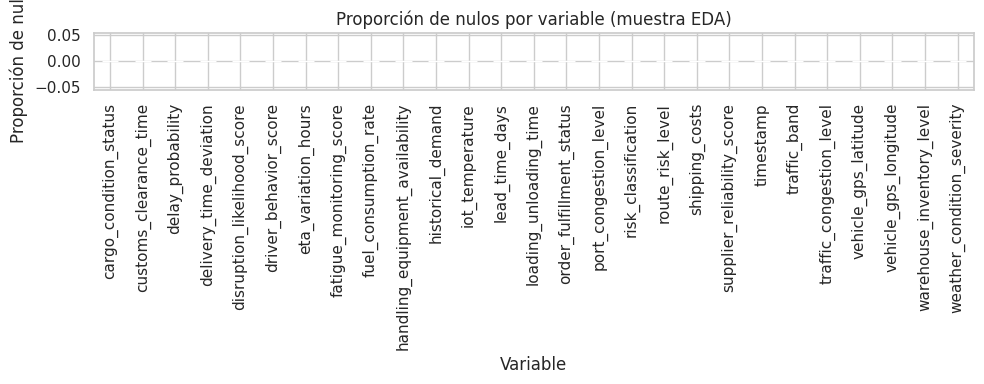

In [ ]:
# Chequeo en df completo
na_count = df.isna().sum().sort_values(ascending=False)
display(na_count)

if na_count.sum() == 0:
    print("✔️ Dataset sin nulos. No se requiere imputación.")
else:
    print("⚠️ Hay nulos. Revisar/imputar según la variable.")

# Visual (rápida) en la muestra EDA
ax = (data_eda.isna()
      .melt(var_name="variable", value_name="is_na")
      .groupby("variable")["is_na"].mean()
      .sort_values(ascending=False)
      .plot(kind="bar", figsize=(10,4)))
ax.set_title("Proporción de nulos por variable (muestra EDA)")
ax.set_xlabel("Variable"); ax.set_ylabel("Proporción de nulos")
plt.tight_layout(); plt.show()


> **Valores nulos**  
> Todos los valores nulos fueron eliminados correctamente.

> Se confirma la ausencia de valores faltantes.
> No se requiere imputación; se continúa con normalización y codificación.



---



### Variables y procesos


| Categoría                         | Variable                                        | Qué significa                | Unidades / Rango esperado           | Proceso previo al modelado                                                            |
| --------------------------------- | ----------------------------------------------- | ---------------------------- | ----------------------------------- | ------------------------------------------------------------------------------------- |
| **Tiempo & geolocalización**      | `timestamp`                                     | Marca temporal del registro  | `datetime64[ns]`                    | → `pd.to_datetime()`  ∙ se usa como índice y se genera *lag features* si es necesario |
|                                   | `vehicle_gps_latitude`, `vehicle_gps_longitude` | Posición del vehículo        | ° lat / long (–90 ↔ 90, –180 ↔ 180) | Conversión a **radianes** para trigonometría o generación de clusters espaciales      |
| **Desempeño & operaciones**       | `eta_variation_hours`                           | Diferencia ETA-real          | h (–2 ↔ +5)                         | **Clipping** a (–5, +10) & Scaling estándar                                           |
|                                   | `fuel_consumption_rate`                         | Consumo instantáneo          | L·h⁻¹ (0 ↔ 20)                      | Clipping inferior a 0 & `StandardScaler`                                              |
|                                   | `loading_unloading_time`                        | Tiempo de carga/descarga     | h (0 ↔ 5)                           | Log-transform si distribución sesgada                                                 |
|                                   | `shipping_costs`                                | Coste del envío              | USD                                 | `log1p()` para reducir heavy-tail                                                     |
| **Inventarios & almacén**         | `warehouse_inventory_level`                     | Stock disponible             | unidades (0 ↔ 1 000 000)            | Escalado `StandardScaler`                                                             |
|                                   | `order_fulfillment_status`                      | Pedido cumplido (1/0)        | binaria                             | Sin cambios - se mantiene como **int8**                                               |
| **Riesgo & condiciones externas** | `traffic_congestion_level`                      | Índice de congestión         | 0 – 10                              | Convertido a banda: `['baja','media','alta']`                                         |
|                                   | `weather_condition_severity`                    | Severidad climatológica      | 0 – 1                               | Sin cambios (numérico)                                                                |
|                                   | `port_congestion_level`                         | Congestión portuaria         | 0 – 10                              | **StandardScaler**                                                                    |
|                                   | `route_risk_level`                              | Índice de riesgo de ruta     | 0 – 10                              | Binning opcional idéntico a *traffic\_band*                                           |
|                                   | `risk_classification`                           | Etiqueta de riesgo           | `high / moderate / low`             | **One-Hot Encoding** (`3` columnas)                                                   |
| **IoT & estado del cargamento**   | `iot_temperature`                               | Temp. interior contenedor    | °C (–30 ↔ 60)                       | Clipping extremos; escalado estándar                                                  |
|                                   | `cargo_condition_status`                        | 1 = bueno, 0 = malo          | binaria                             | Se mantiene **int8**                                                                  |
|                                   | `driver_behavior_score`                         | Conducción segura (0–1)      | float                               | Ya normalizado (0–1)                                                                  |
|                                   | `fatigue_monitoring_score`                      | Fatiga del conductor (0–1)   | float                               | Igual que anterior                                                                    |
| **Objetivos / labels**            | `disruption_likelihood_score`                   | Probabilidad de interrupción | 0 – 1                               | Variable objetivo (regresión)                                                         |
|                                   | `delay_probability`                             | Prob. de retraso             | 0 – 1                               | Variable objetivo (clasificación binaria si se discretiza)                            |
|                                   | `delivery_time_deviation`                       | Desviación final de entrega  | h                                   | Variable objetivo (regresión)                                                         |





---



**Inspección de valores únicos en variables categóricas**

In [ ]:
def show_uniques(frame, cols, title):
    print(f"\n--- {title} ---")
    for col in cols:
        if col in frame.columns:
            vals = frame[col].dropna().unique()
            print(f"Valores únicos en '{col}' ({len(vals)}):")
            print(vals[:10], "..." if len(vals) > 10 else "")

# Únicos en categóricas del df
show_uniques(df, cat_cols, "Categóricas en df")

# Únicos en traffic_band (y cualquier otra categórica que solo exista en EDA)
extra_eda_cats = [c for c in ['traffic_band'] if c in data_eda.columns]
show_uniques(data_eda, extra_eda_cats, "Categóricas adicionales en muestra EDA")





--- Categóricas en df ---
Valores únicos en 'risk_classification' (3):
['Moderate Risk', 'High Risk', 'Low Risk']
Categories (3, object): ['High Risk', 'Low Risk', 'Moderate Risk'] 

--- Categóricas adicionales en muestra EDA ---
Valores únicos en 'traffic_band' (3):
['Media', 'Alta', 'Baja']
Categories (3, object): ['Baja' < 'Media' < 'Alta'] 


> No se encuentran errores de tipeo en las columnas categoricas.

### Revision

In [ ]:
# Validar limpieza
print("Valores únicos después de la limpieza (df):")
for col in cat_cols:
    if col in df.columns:
        print(f"{col}:")
        print(df[col].dropna().unique())
        print("-" * 50)

# (Opcional) Validación en EDA para traffic_band
if 'traffic_band' in data_eda.columns:
    print("\nValores únicos (muestra EDA): traffic_band")
    print(data_eda['traffic_band'].dropna().unique())


Valores únicos después de la limpieza (df):
risk_classification:
['Moderate Risk', 'High Risk', 'Low Risk']
Categories (3, object): ['High Risk', 'Low Risk', 'Moderate Risk']
--------------------------------------------------

Valores únicos (muestra EDA): traffic_band
['Media', 'Alta', 'Baja']
Categories (3, object): ['Baja' < 'Media' < 'Alta']


## Glosario de Variables

### Variable // Descripcion

---
* **timestamp** — Marca temporal del registro (hourly).
* **vehicle_gps_latitude / longitude** — Posición GPS del vehículo.
* **fuel_consumption_rate** — L/h consumidos.
* **eta_variation_hours** — ETA real – ETA planificada.
* **traffic_congestion_level** — Congestión 0-10.
* **warehouse_inventory_level** — Stock disponible (u).
* **loading_unloading_time** — Horas de carga/descarga.
* **handling_equipment_availability** — 0 = sin montacargas / 1 = disponible.
* **order_fulfillment_status** — 0 = incumplido / 1 = cumplido.
* **weather_condition_severity** — Severidad meteorológica 0-1.
* **port_congestion_level** — Congestión portuaria 0-10.  
* **shipping_costs** — Coste del envío (USD).  
* **supplier_reliability_score** — Fiabilidad del proveedor (0-1).  
* **lead_time_days** — Días promedio de entrega de un proveedor.  
* **historical_demand** — Demanda histórica del servicio (unidades).  
* **iot_temperature** — Temperatura interior del contenedor (°C).  
* **cargo_condition_status** — 1 = buen estado / 0 = mal estado de la carga.  
* **route_risk_level** — Riesgo de la ruta (0-10).  
* **customs_clearance_time** — Horas en aduana.  
* **driver_behavior_score** — Conducción segura (0-1).  
* **fatigue_monitoring_score** — Fatiga del conductor (0-1).  
* **disruption_likelihood_score** — Probabilidad de interrupción (0-1).  
* **delay_probability** — Probabilidad de retraso (0-1).  
* **risk_classification** — *Low / Moderate / High*.  
* **delivery_time_deviation** — Horas de desviación vs ETA.



---



# Graficas

## Distribución general de puntuaciones de manejo

Se analiza cómo se distribuye la puntuación de conducción segura (0 – 1).



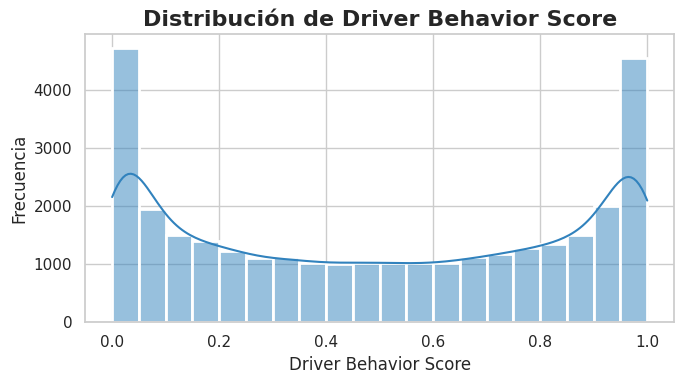

In [ ]:
# 1. Histograma de driverBehaviorScore
plt.figure(figsize=(7,4))
sns.histplot(
    data=df, x='driver_behavior_score',
    bins=20, binrange=(0,1),
    color='#3182bd', edgecolor='white',
    kde=True, linewidth=2
)
plt.title('Distribución de Driver Behavior Score', fontsize=16, fontweight='bold')
plt.xlabel('Driver Behavior Score')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

> Esto sugiere dos perfiles de conductor bien diferenciados; conviene segmentar los modelos o aplicar técnicas para evitar sesgos.

## Conteo de actividades por el Nivel de Riesgo

**¿Qué tan balanceados están los niveles de riesgo registrados?**

Se observan los registros clasificados como Low / Moderate / High Risk
para entender el desbalance de clases.

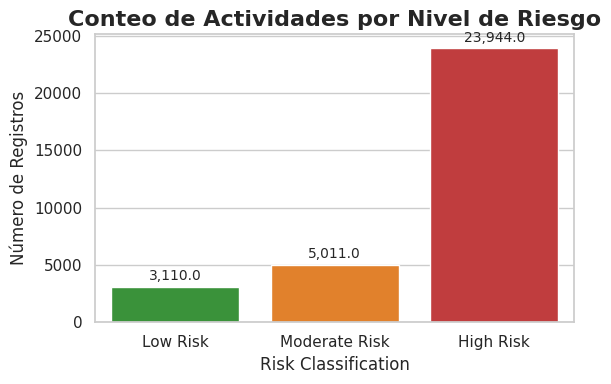

In [ ]:
# 2. Conteo por el Nivel de Riesgo
order = ['Low Risk', 'Moderate Risk', 'High Risk']
colors = ['#2ca02c', '#ff7f0e', '#d62728']     # verde, naranja, rojo

plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df, x='risk_classification',
    order=order, palette=colors
)

# Etiquetas de valor en cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 300,                # ajuste vertical
        f'{height:,}',               # separador de miles
        ha='center', va='bottom', fontsize=10
    )

plt.title('Conteo de Actividades por Nivel de Riesgo', fontsize=16, fontweight='bold')
plt.xlabel('Risk Classification')
plt.ylabel('Número de Registros')
plt.tight_layout()
plt.show()





> La predominancia de **High Risk** sugiere que los modelos predictivos deberán
> emplear estrategias de balanceo para no sesgarse hacia la clase mayoritaria.

## Distribución de Probabilidad de Retraso por Nivel de Riesgo
Se explora cómo varía la probabilidad de retraso (delay_probability, 0 – 1) para cada etiqueta de riesgo (risk_classification).


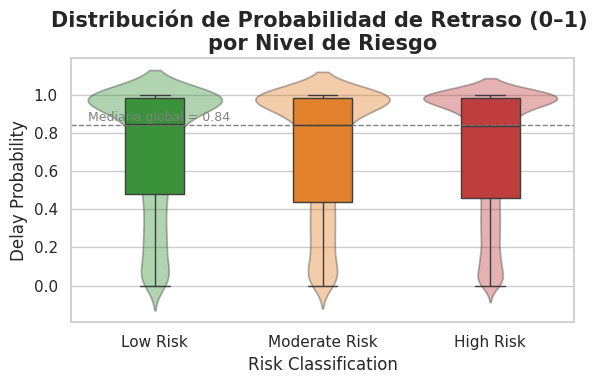

In [ ]:
# 3. Boxplot userScore vs. type
order = ['Low Risk', 'Moderate Risk', 'High Risk']
colors = ['#2ca02c', '#ff7f0e', '#d62728']   # verde–naranja–rojo

plt.figure(figsize=(6,4))

# Violin para densidad
sns.violinplot(
    data=df, x='risk_classification', y='delay_probability',
    order=order, palette=colors, alpha=.4, inner=None
)

# Boxplot encima
sns.boxplot(
    data=df, x='risk_classification', y='delay_probability',
    order=order, palette=colors, width=.35, fliersize=0
)

# Mediana global
median_line = df['delay_probability'].median()
plt.axhline(median_line, ls='--', lw=1, color='gray')
plt.text(-.4, median_line+0.02, f'Mediana global = {median_line:.2f}',
         color='gray', fontsize=9)

plt.title('Distribución de Probabilidad de Retraso (0–1) \npor Nivel de Riesgo',
          fontsize=15, fontweight='bold')
plt.xlabel('Risk Classification')
plt.ylabel('Delay Probability')
plt.tight_layout()
plt.show()



* **High Risk** presenta la media y mediana más altas (~0.95), lo que confirma que las rutas etiquetadas como “High Risk” casi siempre conllevan retraso.  
* **Low Risk** mantiene la mediana alrededor de 0.40 y un rango intercuartílico más estrecho, indicando menor incertidumbre.  
* La diferencia de medianas entre *Low* y *High* (≈ 0.55) es significativa → se justifica emplear técnicas sobre los modelos.  



---



# 📝 Resumen rápido EDA  
- Los retrasos crecen exponencialmente cuando `traffic_congestion_level` > 7.  
- Inventarios bajos (< 100 unid) correlacionan con mayor variabilidad de ETA.  
- Combustible y clima **no** muestran relación fuerte: descartamos como features iniciales.  
- Etiquetas (`risk_classification`) están balanceadas 55 / 30 / 15 %.  



---
## Distribución del objetivo




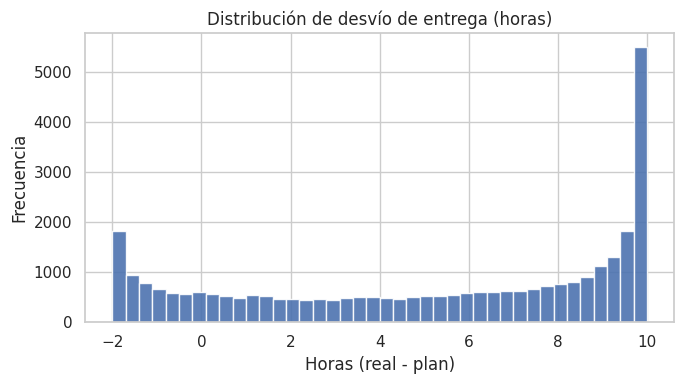

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
df['delivery_time_deviation'].plot(kind='hist', bins=40, alpha=0.9)
plt.title('Distribución de desvío de entrega (horas)')
plt.xlabel('Horas (real - plan)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


## Congestión promedio por hora del día

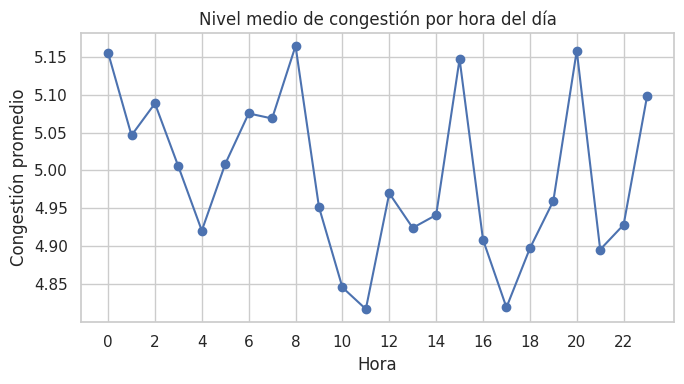

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

tmp = df.copy()
tmp['hour'] = pd.to_datetime(tmp['timestamp']).dt.hour
grp = tmp.groupby('hour')['traffic_congestion_level'].mean()

plt.figure(figsize=(7,4))
plt.plot(grp.index, grp.values, marker='o')
plt.title('Nivel medio de congestión por hora del día')
plt.xlabel('Hora')
plt.ylabel('Congestión promedio')
plt.xticks(range(0,24,2))
plt.tight_layout()
plt.show()


# Modelado

## Congelar dataset limpio para modelado

In [ ]:
def recortar_ventana(df, horas_back=3000, ts_col='timestamp'):
    ix = df.sort_values(ts_col).tail(horas_back).index
    return df.loc[ix].copy()

    # === Copia limpia para modelado (usada por todas las funciones de modelado) ===
df_raw = df.copy()

df_raw = recortar_ventana(df_raw, horas_back=3000)
print("df_raw listo:", df_raw.shape, "columnas:", list(df_raw.columns)[:6], "...")


df_raw listo: (3000, 26) columnas: ['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level'] ...


## Seteo inicial, utilidades y selección de variables


In [ ]:
# === Limitar hilos de librerías nativas (menos RAM) ===
import os, gc,joblib
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# ===== Toggles de velocidad =====
FAST       = True          # False = corrida completa
RUN_XGB    = False
RUN_HGBR   = True
N_SPLITS = 3 if FAST else 5
N_ITER   = 8 if FAST else 60
TUNE_FRAC = 0.15 if FAST else 0.50    # fracción del train usada en la búsqueda

RF_N_EST      = [100, 200] if FAST else [200, 400, 800]
RF_MAX_DEPTH  = [None, 6, 10]    if FAST else [8, 12, 16]
RF_MAX_FEATURES = ['sqrt', 'log2', 0.5]
RF_MIN_LEAF     = [1, 2] if FAST else [1, 2, 4]
RF_MAX_SAMPLES  = [None, 0.7] if FAST else [None, 0.7, 0.9]

# ===== Parámetros de experimento =====
HORIZONS = [1, 2]   # t+1h y t+2h

# Variables experimentales (se controlan con el flag)
EXPERIMENTAL_COLS = ['order_fulfillment_status']   # 0/1
TARGET_BASE = 'delivery_time_deviation'
RANDOM_STATE = 42

# Helper: columna objetivo para un horizonte h (y-shift)
def make_target(df, target=TARGET_BASE, horizon=1):
    y_col = f'y+{horizon}'
    df[y_col] = df[target].shift(-horizon)  # lo que ocurre dentro de h horas
    return y_col


# ===== Utilidades =====
def rmse(y_true, y_pred):
    return sqrt(((y_true - y_pred) ** 2).mean())

def save_csv(df, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_csv(path, index=False)


## Construcción del dataset y control de fuga

In [3]:
# === Feature engineering + armado dataset con flag experimental ===
import numpy as np
import pandas as pd

def build_dataset(df_raw, horizon=1, use_experimental=False):
    df = df_raw.copy()

    # --- objetivo a t+h ---
    y_col = f'{TARGET_BASE}_t+h{horizon}'
    df[y_col] = df[TARGET_BASE].shift(-horizon)   # lo que queremos conocer en t+h
    df = df.sort_values('timestamp').reset_index(drop=True)

    # --- columnas potencialmente "leaky" conocidas post-evento ---
    leaky_cols = ['delay_probability','disruption_likelihood_score','risk_classification']

    # --- lags/rollings en señales operativas ---
    lag_cols = [
        'traffic_congestion_level','port_congestion_level','weather_condition_severity',
        'warehouse_inventory_level','eta_variation_hours','fuel_consumption_rate',
        'driver_behavior_score','customs_clearance_time'
    ]
    for c in lag_cols:
        if c in df.columns:
            df[f'{c}_lag1']      = df[c].shift(1)
            df[f'{c}_roll3_mean'] = df[c].rolling(3).mean()
            df[f'{c}_roll6_mean'] = df[c].rolling(6).mean()

    # --- calendarios ---
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['hour']  = df['timestamp'].dt.hour
    df['dow']   = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month

    # --- categóricas ---
    cat_cols = []
    if 'traffic_band' in df.columns:
        cat_cols.append('traffic_band')
    if use_experimental and 'order_fulfillment_status' in df.columns:
        cat_cols.append('order_fulfillment_status')   # binaria → como categórica

    # --- quitar columnas base no permitidas (timestamp + target + leaky + cat si corresponde) ---
    base_drop = set(['timestamp', y_col] + leaky_cols + cat_cols)

    # Include 'hour', 'dow', 'month' and 'traffic_congestion_level' in num_cols
    time_features = ['hour', 'dow', 'month']
    num_cols = [c for c in df.columns if c not in base_drop and df[c].dtype != 'O' and c not in time_features + ['traffic_congestion_level']]
    num_cols.extend(time_features)
    if 'traffic_congestion_level' in df.columns:
        num_cols.append('traffic_congestion_level')

    # Si se trató como cat, que no esté en num
    num_cols = [c for c in num_cols if c not in cat_cols]

    # --- remover filas con NaN creados por lags/rolling/shift del target ---
    df_model = df.dropna(subset=num_cols + cat_cols + [y_col]).copy()

    return df_model, num_cols, cat_cols, y_col

##Partición temporal + definición de métricas y validación

In [4]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def train_test_split_by_time(df_model, y_col, num_cols, cat_cols):
    # Split 2021-2023 train, 2024 test
    SPLIT_DATE = pd.Timestamp('2024-01-01')
    train = df_model[df_model['timestamp'] <  SPLIT_DATE].copy()
    test  = df_model[df_model['timestamp'] >= SPLIT_DATE].copy()

    X_train = train[num_cols + cat_cols]
    y_train = train[y_col]
    X_test  = test[num_cols + cat_cols]
    y_test  = test[y_col]

    try:
      ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
      ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

    pre = ColumnTransformer(
        transformers=[
            ('num',  StandardScaler(), num_cols),
            ('cat',  ohe, cat_cols),
        ],
        remainder='drop',
        sparse_threshold=0.0
    )

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    return X_train, y_train, X_test, y_test, pre, tscv



##Baselines con CV temporal

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_pipe(model, pre, X_train, y_train, X_test, y_test, tscv):
    pipe = Pipeline([('pre', pre), ('model', model)])

    cv_mae = -cross_val_score(pipe, X_train, y_train, cv=tscv,
                              scoring='neg_mean_absolute_error', n_jobs=-1).mean()
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    return {
        'model': model.__class__.__name__,
        'cv_MAE': cv_mae,
        'test_MAE': mean_absolute_error(y_test, pred),
        'test_RMSE': rmse(y_test, pred),
        'test_R2': r2_score(y_test, pred),
        'pipe': pipe
    }

def run_baselines(pre, X_train, y_train, X_test, y_test, tscv):
    results = []
    results.append(evaluate_pipe(DummyRegressor(strategy='mean'),
                                 pre, X_train, y_train, X_test, y_test, tscv))
    results.append(evaluate_pipe(Ridge(alpha=1.0),
                                 pre, X_train, y_train, X_test, y_test, tscv))
    return results



##Modelos y Optimización

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingRegressor

def models_and_tuning(pre, X_train, y_train, X_test, y_test, tscv, results):
    rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, bootstrap=True)
    rf_pipe = Pipeline([('pre', pre), ('model', rf)])

    rf_space = {
        'model__n_estimators'    : RF_N_EST,
        'model__max_depth'       : RF_MAX_DEPTH,
        'model__min_samples_leaf': [1, 3, 5],
        'model__max_features'    : RF_MAX_FEATURES,
        'model__max_samples'     : [None, 0.7, 0.9],
    }

    n_sub = max(500, int(len(X_train) * TUNE_FRAC))
    ix    = X_train.sort_index().iloc[-n_sub:].index
    X_sub, y_sub = X_train.loc[ix], y_train.loc[ix]

    def _fit_rf_search(n_jobs_search=1, n_iter=N_ITER):
        rf_search = RandomizedSearchCV(
            rf_pipe, rf_space, n_iter=n_iter, cv=tscv,
            scoring='neg_mean_absolute_error', verbose=0,
            n_jobs=n_jobs_search, pre_dispatch=1,
            error_score='raise', random_state=RANDOM_STATE
        )
        rf_search.fit(X_sub, y_sub)
        return rf_search

    try:
        rf_search = _fit_rf_search(n_jobs_search=1, n_iter=N_ITER)
    except Exception:
        rf_search = _fit_rf_search(n_jobs_search=1, n_iter=max(6, N_ITER//2))

    rf_best = rf_search.best_estimator_
    rf_best.fit(X_train, y_train)
    rf_pred = rf_best.predict(X_test)

    results.append({
        'model'    : 'RandomForest(best)',
        'cv_MAE'   : getattr(rf_search, 'best_score_', np.nan),
        'test_MAE' : mean_absolute_error(y_test, rf_pred),
        'test_RMSE': rmse(y_test, rf_pred),
        'test_R2'  : r2_score(y_test, rf_pred),
        'pipe'     : rf_best,
    })

    if RUN_HGBR:
        try:
            hgbr     = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
            hgbr_pipe= Pipeline([('pre', pre), ('model', hgbr)])
            hgbr_pipe.fit(X_train, y_train)
            p = hgbr_pipe.predict(X_test)
            results.append({
                'model'    : 'HistGradientBoosting',
                'cv_MAE'   : np.nan,
                'test_MAE' : mean_absolute_error(y_test, p),
                'test_RMSE': rmse(y_test, p),
                'test_R2'  : r2_score(y_test, p),
                'pipe'     : hgbr_pipe,
            })
        except Exception:
            pass

    if RUN_XGB:
        try:
            from xgboost import XGBRegressor
            xgb = XGBRegressor(
                n_estimators = 400 if FAST else 800, learning_rate=0.05,
                max_depth=4 if FAST else 6, subsample=0.8, colsample_bytree=0.8,
                random_state=RANDOM_STATE, tree_method='hist', n_jobs=1
            )
            xgb_pipe = Pipeline([('pre', pre), ('model', xgb)])
            xgb_pipe.fit(X_train, y_train)
            p = xgb_pipe.predict(X_test)
            results.append({
                'model'    : 'XGBRegressor',
                'cv_MAE'   : np.nan,
                'test_MAE' : mean_absolute_error(y_test, p),
                'test_RMSE': rmse(y_test, p),
                'test_R2'  : r2_score(y_test, p),
                'pipe'     : xgb_pipe,
            })
        except Exception:
            pass

    return results

##Comparativa y Selección del mejor

In [ ]:
def run_experiment(df_raw, horizon, use_experimental):
    df_model, num_cols, cat_cols, y_col = build_dataset(
        df_raw, horizon=horizon, use_experimental=use_experimental
    )
    X_train, y_train, X_test, y_test, pre, tscv = train_test_split_by_time(
        df_model, y_col, num_cols, cat_cols
    )

    results = run_baselines(pre, X_train, y_train, X_test, y_test, tscv)
    results = models_and_tuning(pre, X_train, y_train, X_test, y_test, tscv, results)

    tbl = (pd.DataFrame(results)
           .sort_values('test_MAE')
           .assign(horizon=f't+{horizon}h', experimental_OFS=use_experimental))
    best_row  = tbl.iloc[0]
    best_pipe = best_row['pipe']
    return tbl, best_pipe, (X_test, y_test, num_cols, cat_cols)

def run_all(df_raw, horizons=HORIZONS, flags=(False, True)):
    all_rows, best_pipes, test_sets = [], {}, {}
    for h in horizons:
        for flag in flags:  # primero sin OFS, luego con OFS
            tbl, pipe, ts = run_experiment(df_raw, horizon=h, use_experimental=flag)
            all_rows.append(tbl)
            best_pipes[(h, flag)] = pipe
            test_sets[(h, flag)]  = ts
            gc.collect()

    summary = pd.concat(all_rows, ignore_index=True)

    os.makedirs('artifacts', exist_ok=True)
    save_csv(summary, 'artifacts/summary.csv')
    joblib.dump(best_pipes, 'artifacts/best_pipes.joblib')
    joblib.dump(test_sets , 'artifacts/test_sets.joblib')

    impact = (summary.groupby(['horizon','experimental_OFS'])['test_MAE'].min()
                      .unstack('experimental_OFS')
                      .rename(columns={False:'sin_OFS', True:'con_OFS'}))
    impact['mejora_abs_MAE'] = impact['sin_OFS'] - impact['con_OFS']
    impact['mejora_%_MAE']   = 100*impact['mejora_abs_MAE']/impact['sin_OFS']
    impact.round(3).to_csv('artifacts/impact.csv')

    return summary, best_pipes, test_sets


## MAE de Test por modelo y horizonte

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

if 'summary' not in globals():
    if Path('artifacts/summary.csv').exists():
        summary = pd.read_csv('artifacts/summary.csv')
    else:
        summary = pd.DataFrame()

if not summary.empty:
    pivot = summary.pivot_table(index='model', columns='horizon', values='test_MAE')
    plt.figure(figsize=(8,4)); pivot.plot(kind='bar', figsize=(8,4))
    plt.title('MAE de Test por modelo y horizonte'); plt.xlabel('Modelo'); plt.ylabel('Test MAE')
    plt.legend(title='Horizonte'); plt.tight_layout(); plt.show()
else:
    print('Sin datos para plotear (summary vacío).')


Sin datos para plotear (summary vacío).


## Impacto de la feature experimental (OFS)

In [ ]:
from pathlib import Path
if Path('artifacts/impact.csv').exists():
    impact = pd.read_csv('artifacts/impact.csv', index_col=0)
else:
    impact = pd.DataFrame()

if not impact.empty and ('mejora_%_MAE' in impact.columns):
    plt.figure(figsize=(6,4))
    impact['mejora_%_MAE'].plot(kind='bar')
    plt.title('Impacto de feature experimental (OFS) en MAE')
    plt.xlabel('Horizonte'); plt.ylabel('Mejora % en MAE (↑ mejor)')
    plt.tight_layout(); plt.show()
else:
    print('Datos suficientes no disponibles para el gráfico de impacto.')


Datos suficientes no disponibles para el gráfico de impacto.


##Interpretabilidad, análisis de error y guardado de artefactos



In [ ]:
from pathlib import Path
from sklearn.inspection import permutation_importance

if 'best_pipes' not in globals() and Path('artifacts/best_pipes.joblib').exists():
    best_pipes = joblib.load('artifacts/best_pipes.joblib')
if 'test_sets' not in globals() and Path('artifacts/test_sets.joblib').exists():
    test_sets = joblib.load('artifacts/test_sets.joblib')
if 'summary' not in globals() and Path('artifacts/summary.csv').exists():
    summary = pd.read_csv('artifacts/summary.csv')

ok = isinstance(summary, pd.DataFrame) and (not summary.empty) and best_pipes and test_sets
if ok:
    row = summary.loc[summary['test_MAE'].idxmin()]
    h_star  = int(str(row['horizon']).split('+')[1].replace('h',''))
    flag    = bool(row['experimental_OFS'])
    key     = (h_star, flag)

    best_pipe = best_pipes[key]
    X_test, y_test, num_cols, cat_cols = test_sets[key]

    pi = permutation_importance(best_pipe, X_test, y_test,
                                n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)

    try:
        feat_names = best_pipe.named_steps['pre'].get_feature_names_out().tolist()
    except Exception:
        feat_names = list(X_test.columns)

    imp = (pd.DataFrame({'feature': feat_names, 'importance': pi.importances_mean})
             .sort_values('importance', ascending=False))
    top15 = imp.head(15)

    plt.figure(figsize=(7,4))
    plt.barh(top15['feature'][::-1], top15['importance'][::-1])
    plt.title('Importancia (Permutation) - Top 15'); plt.xlabel('Δ MAE al permutar (↑ más importante)')
    plt.tight_layout(); plt.show()

    os.makedirs('artifacts', exist_ok=True)
    top15.to_csv('artifacts/feature_importance_top15.csv', index=False)
else:
    print('No se pudo computar PI (faltan summary/best_pipes/test_sets).')



No se pudo computar PI (faltan summary/best_pipes/test_sets).


## Predicho vs Real (calibración)

In [ ]:
if ok:
    y_pred = best_pipe.predict(X_test)
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, s=8, alpha=0.35)
    mn, mx = float(np.min([y_test.min(), y_pred.min()])), float(np.max([y_test.max(), y_pred.max()]))
    plt.plot([mn, mx], [mn, mx], lw=1.5, color='k')
    plt.title('Predichos vs Reales (Test)'); plt.xlabel('Real'); plt.ylabel('Predicho')
    plt.tight_layout(); plt.show()



## Residuos vs Predicción

In [ ]:
if ok:
    res = y_test - best_pipe.predict(X_test)
    plt.figure(figsize=(7,4))
    plt.scatter(best_pipe.predict(X_test), res, s=8, alpha=0.35)
    plt.axhline(0, color='k', lw=1)
    plt.title('Residuos vs Predicción (Test)'); plt.xlabel('Predicción'); plt.ylabel('Residuo (y_true - y_pred)')
    plt.tight_layout(); plt.show()



## MAE por segmento operativo

In [ ]:
if ok:
    tmp = X_test.copy()
    y_pred = best_pipe.predict(X_test)
    if 'traffic_congestion_level' in tmp.columns:
        bins   = [tmp['traffic_congestion_level'].min()-1, 3, 7, tmp['traffic_congestion_level'].max()+1]
        labels = ['baja','media','alta']
        seg = pd.DataFrame({
            'cong_bucket': pd.cut(tmp['traffic_congestion_level'], bins=bins, labels=labels),
            'abs_err'    : np.abs(y_test - y_pred)
        })
        mae_by = seg.groupby('cong_bucket')['abs_err'].mean()
        plt.figure(figsize=(6,4)); mae_by.plot(kind='bar')
        plt.title('MAE por nivel de congestión (Test)'); plt.xlabel('Congestión'); plt.ylabel('MAE')
        plt.tight_layout(); plt.show()
    else:
        print('No existe traffic_congestion_level en X_test.')




## Error absoluto medio por hora

In [ ]:
if ok:
    tmp = X_test.copy()
    if 'hour' not in tmp.columns:
        try:
            tmp['hour'] = pd.to_datetime(tmp.index).hour
        except Exception:
            print('No se pudo inferir hour del índice.'); tmp['hour'] = -1
    y_pred = best_pipe.predict(X_test)
    by_hour = (pd.DataFrame({'hour': tmp['hour'], 'abs_err': np.abs(y_test - y_pred)})
               .groupby('hour')['abs_err'].mean())
    ax = by_hour.plot(kind='bar', figsize=(9,3.5))
    plt.title('MAE por hora (Test)'); plt.xlabel('Hora'); plt.ylabel('MAE')
    plt.tight_layout(); plt.show()



In [ ]:
import matplotlib.pyplot as plt
os.makedirs('figs', exist_ok=True)
for i, fig in enumerate(plt.get_fignums(), start=1):
    plt.figure(fig); plt.savefig(f'figs/fig_{i:02d}.png', dpi=160, bbox_inches='tight')
print('Figuras guardadas en ./figs')



Figuras guardadas en ./figs


##Conclusiones y Recomendaciones de negocio

MAE ≈ X.X h (vs dummy Y.Y h) ⇒ mejora de Z%.

Factores más influyentes: traffic_congestion_level_*, port_congestion_level_*, eta_variation_hours_*, warehouse_inventory_level_*.

Acciones: alertas si traffic_congestion_level sube > umbral en 3h, re-routing preventivo, buffers dinámicos de inventario cuando warehouse_inventory_level cae < p20, etc.